# Introduction

This notebook is meant to explore how reducers (in LangGraph) work.

# Import

In [57]:
from typing import TypedDict, Annotated
from operator import add
from langchain_core.messages import AIMessage, HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display

# Default: Overwriting the State

In [2]:
# Creating a TypeDict State
class State(TypedDict):
    name: str
    score: int

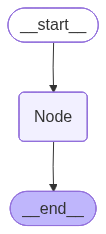

In [16]:
# Building a graph with a single node
def node(state):
    return {"score": state["score"] + 1}

builder = StateGraph(State)
builder.add_node("Node", node)
builder.add_edge(START, "Node")
builder.add_edge("Node", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"name": "Alice", "score": 10})

{'name': 'Alice', 'score': 11}

Note: Here, the values in state are getting overwritten

# Branching

Observing what happens when 2 nodes simultaneously try to update the same value.

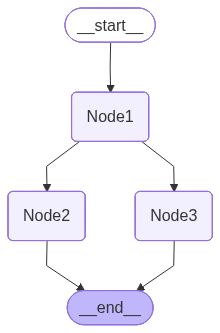

In [40]:
def node1(state):
    print(f"=== Node1 ===")
    print(f"Input state: {state}")
    return {"score": 0}

def node2(state):
    print(f"=== Node2 ===")
    print(f"Input state: {state}")
    return {"score": 1}

def node3(state):
    print(f"=== Node3 ===")
    print(f"Input state: {state}")
    return {"score": 2}

# Defining a function to build the graph with multiple nodes and edges
def get_builder(statetype):
    builder = StateGraph(statetype)
    builder.add_node("Node1", node1)
    builder.add_node("Node2", node2)
    builder.add_node("Node3", node3)
    builder.add_edge(START, "Node1")
    builder.add_edge("Node1", "Node2")
    builder.add_edge("Node1", "Node3")
    builder.add_edge("Node2", END)
    builder.add_edge("Node3", END)
    return builder

builder = get_builder(State)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
try:
    graph.invoke({"name": "Alice", "score": 1})
except Exception as e:
    print(f"Error: {e}")

=== Node1 ===
Input state: {'name': 'Alice', 'score': 1}
=== Node2 ===
Input state: {'name': 'Alice', 'score': 0}
=== Node3 ===
Input state: {'name': 'Alice', 'score': 0}
Error: At key 'score': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


Steps:
1. Score at invoke =1 and this is sent to Node1
2. Node1 overwrites score to 0
3. Node2 and Node3 get the sate and are both intending to overwrite Score - throwing an error


Node2 and Node3 are trying to overwrite the same element. This is not allowed.

In [43]:
class AnnotatedState(TypedDict):
    name: str
    score: Annotated[int, add]

In [44]:
builder2 = get_builder(AnnotatedState)
graph2 = builder2.compile()

In [46]:
graph2.invoke({"name": "Alice", "score": 1})

=== Node1 ===
Input state: {'name': 'Alice', 'score': 1}
=== Node2 ===
Input state: {'name': 'Alice', 'score': 1}
=== Node3 ===
Input state: {'name': 'Alice', 'score': 1}


{'name': 'Alice', 'score': 4}

Steps:
1. Score is set to 1 an invoke and sent to Node1
2. Node1 is not overwriting the score, the reducer function (operator.add) is used - Node1 is adding the current value of score (1) with the value that is being sent back by Node1 (0) - (1+0 =1)
3. Score value is 1 as it is simultaneously sent to Node2 and Node3 - Node2 returns a value of 1 which is getting added and Node3 returns a value of 2 which is also getting simultaneously added (to the input value of score=1) to a total of 4

Both updates from Node2 and Node3 are happening by invoking the reducer function.

# Custom Reducer

In [47]:
def custom_reducer(left, right):
    print(f"=== Custom Reducer ===")
    print(f"Left: {left}, Right: {right}")
    return left + right

In [48]:
class CustomReducerState(TypedDict):
    name: str
    score: Annotated[int, custom_reducer]

In [49]:
builder3 = get_builder(CustomReducerState)
graph3 = builder3.compile()

In [50]:
graph3.invoke({"name": "Alice", "score": 1})

=== Custom Reducer ===
Left: 0, Right: 1
=== Node1 ===
Input state: {'name': 'Alice', 'score': 1}
=== Custom Reducer ===
Left: 1, Right: 0
=== Node2 ===
Input state: {'name': 'Alice', 'score': 1}
=== Node3 ===
Input state: {'name': 'Alice', 'score': 1}
=== Custom Reducer ===
Left: 1, Right: 1
=== Custom Reducer ===
Left: 2, Right: 2


{'name': 'Alice', 'score': 4}

Note: From here, we can see that the Nodes are first loaded and the reducer is getting repeatedly called based on the number of nodes present in the same step

# Reducer for Messages (add_message)

From previous module, we know that add_message appends messages.

We know that this class...
```
class CustomMessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    added_key_1: str
    added_key_2: str
```

Is the same as this class...
```
class ExtendedMessagesState(MessagesState):
    # messages key with Annotated add_messages reducer is pre-built 
    added_key_1: str
    added_key_2: str
```

Lets explore the capabilities of the add_messages function

### Appending Messages

In [55]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='f4bb6217-e58c-444f-b2e7-079d0ac2cc30', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='c4094b72-d3c0-4bfa-98eb-6fd4e714465c'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='3a592b66-30fd-40d4-aadd-5890c42c925e', tool_calls=[], invalid_tool_calls=[])]

Note:
1. The add_message function (reducer) appended the new message to the list of initial messages
2. Also, note, each message will have a default 'id' assigned to it

### Re-Writing Messages

Let us define the 'id' of each message

In [56]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model", id=1),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance", id=2)
                   ]

# Adding message with an existing 'id'
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model", id=1)

add_messages(initial_messages, new_message)

[AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='2')]

Note: The previous message with the same 'id' was overwritten

### Removing Messages

In [59]:
# Message list
messages = [AIMessage("Hi.", name="Bot", id=1)]
messages.append(HumanMessage("Hi.", name="Lance", id=2))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id=3))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id=4))

# Isolate messages to delete
delete_messages = [RemoveMessage(id=2), RemoveMessage(id=4)]
delete_messages

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='4')]

In [60]:
add_messages(messages, delete_messages)

[AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[])]

Note: The messages with the listed 'id' in RemoveMessages have been removed.